# Attention Network for NLP Seq2Seq Tasks (Toy Example)

## Introduction

An **Attention Network** is a neural network architecture that allows the model to focus on the most relevant parts of the input sequence when generating each part of the output. In simple terms, attention computes a set of weights ("how much to look at each input token") for every output token, enabling the model to dynamically select important information. Mathematically, attention scores are computed (often as dot products or learned functions), normalized (softmax), and used to create a weighted sum of input features. The key component is the **attention mechanism**, which is now foundational in modern NLP models like Transformers.

**Applications:**
- Machine translation (e.g., English to French)
- Text summarization
- Question answering
- Sentiment analysis (e.g., sarcasm detection)
- Research assistants 

**Why choose Attention for this demo?**
Attention is chosen for NLP seq2seq tasks because it helps the model focus on relevant parts of the input, especially for longer or more complex sequences. This is crucial in tasks like translation, where different output words may depend on different input words. For this demo, we'll use toy data (short sequence pairs) to keep things simple and fast, but the principles apply to real-world NLP tasks.

In [1]:
# Setup: Import libraries and create toy dataset
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Why: TensorFlow/Keras for model, NumPy for data, Matplotlib for plots, sklearn for splitting

# Create toy sequence-to-sequence data (e.g., reverse sequences)
# Input: sequences of integers, Output: reversed sequences
vocab_size = 12  # Small vocab for demo
seq_length = 5
num_samples = 3000

np.random.seed(42)
X = np.random.randint(1, vocab_size, size=(num_samples, seq_length))
Y = np.flip(X, axis=1)  # Reverse the sequence

# Why: Simple task (reversing) to demonstrate attention, keeps training fast

# One-hot encode outputs for categorical_crossentropy
Y_oh = keras.utils.to_categorical(Y, num_classes=vocab_size)

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_oh, test_size=0.2, random_state=42)
# Why: Train-test split evaluates generalization

print('Sample input:', X_train[0])
print('Sample output:', np.argmax(Y_train[0], axis=-1))

Sample input: [ 8  4  1  1 10]
Sample output: [10  1  1  4  8]


## Model Building: Simple Seq2Seq with Attention

This section builds a simple sequence-to-sequence (seq2seq) model with an attention mechanism, a foundational architecture in modern NLP for tasks like translation, summarization, and more.

### Encoder

The **encoder** processes the input sequence and summarizes it into a set of hidden states:

- **Input Layer:**  
  `encoder_inputs = keras.Input(shape=(seq_length,))`  
  The encoder receives a sequence of integer tokens (e.g., word indices).

- **Embedding Layer:**  
  `enc_emb = layers.Embedding(input_dim=vocab_size, output_dim=16, mask_zero=True)(encoder_inputs)`  
  Each token is mapped to a dense vector (embedding), allowing the model to learn semantic relationships between tokens.

- **LSTM Layer:**  
  `encoder_lstm = layers.LSTM(32, return_sequences=True, return_state=True)`  
  `encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)`  
  The LSTM processes the sequence, outputting a sequence of hidden states (`encoder_outputs`) and the final hidden and cell states (`state_h`, `state_c`).  
  - **Mathematically:**  
    For each time step $t$, the LSTM computes:
    $$
    h_t, c_t = \text{LSTM}(x_t, h_{t-1}, c_{t-1})
    $$
    where $x_t$ is the input embedding at time $t$, $h_{t-1}$ and $c_{t-1}$ are the previous hidden and cell states.

### Decoder

The **decoder** generates the output sequence, one token at a time, using the encoder's context:

- **Input Layer:**  
  `decoder_inputs = keras.Input(shape=(seq_length,))`  
  The decoder receives the previous output tokens (teacher forcing during training).

- **Embedding Layer:**  
  `dec_emb = layers.Embedding(input_dim=vocab_size, output_dim=16, mask_zero=True)(decoder_inputs)`

- **LSTM Layer:**  
  `decoder_lstm = layers.LSTM(32, return_sequences=True, return_state=True)`  
  `decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])`  
  The decoder LSTM is initialized with the encoder's final states, allowing it to condition its generation on the input sequence.

### Attention Mechanism

The **attention layer** allows the decoder to focus on relevant parts of the input sequence at each output step:

- **Additive Attention:**  
  `attention = layers.AdditiveAttention()`  
  `attention_out = attention([decoder_outputs, encoder_outputs])`  
  For each decoder time step $t$, attention computes a context vector as a weighted sum of encoder outputs:
  $$
  \text{score}(s_t, h_i) = v^T \tanh(W_1 h_i + W_2 s_t)
  $$
  $$
  \alpha_{t,i} = \frac{\exp(\text{score}(s_t, h_i))}{\sum_j \exp(\text{score}(s_t, h_j))}
  $$
  $$
  \text{context}_t = \sum_i \alpha_{t,i} h_i
  $$
  where $h_i$ are encoder outputs, $s_t$ is the decoder state at time $t$, and $\alpha_{t,i}$ are the attention weights.

- **Concatenation:**  
  `concat = layers.Concatenate()([decoder_outputs, attention_out])`  
  The decoder's output and the context vector are concatenated, providing the decoder with both its own state and the attended encoder information.

### Output Layer

- **TimeDistributed Dense Layer:**  
  `outputs = layers.TimeDistributed(layers.Dense(vocab_size, activation='softmax'))(concat)`  
  For each time step, the model predicts a probability distribution over the vocabulary.

### Model Compilation

- **Optimizer:**  
  `optimizer='adam'`  
  Adam is chosen for its adaptive learning rate and fast convergence.

- **Loss:**  
  `loss='categorical_crossentropy'`  
  Suitable for multi-class sequence prediction, as each output token is a class.

- **Metrics:**  
  `metrics=['accuracy']`  
  Accuracy is intuitive for sequence tasks, measuring how often the predicted tokens match the targets.

---

**Summary:**  
This architecture enables the model to learn which parts of the input sequence are most relevant for generating each output token, overcoming the limitations of fixed-length context vectors in vanilla seq2seq models. The attention mechanism is mathematically elegant and practically powerful, forming the basis for advanced models like Transformers.

In [2]:
# Model Building: Simple Seq2Seq with Attention
# Encoder
encoder_inputs = keras.Input(shape=(seq_length,))
enc_emb = layers.Embedding(input_dim=vocab_size, output_dim=16, mask_zero=True)(encoder_inputs)
encoder_lstm = layers.LSTM(32, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# Decoder
decoder_inputs = keras.Input(shape=(seq_length,))
dec_emb = layers.Embedding(input_dim=vocab_size, output_dim=16, mask_zero=True)(decoder_inputs)
decoder_lstm = layers.LSTM(32, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# Attention mechanism
attention = layers.AdditiveAttention()  # Why: Additive attention is simple and effective
attention_out = attention([decoder_outputs, encoder_outputs])
concat = layers.Concatenate()([decoder_outputs, attention_out])

# Output layer
outputs = layers.TimeDistributed(layers.Dense(vocab_size, activation='softmax'))(concat)

model = keras.Model([encoder_inputs, decoder_inputs], outputs)

# Compile model
model.compile(optimizer='adam',  # Why Adam: Adaptive learning rate for faster convergence
              loss='categorical_crossentropy',  # Why: Multi-class sequence prediction
              metrics=['accuracy'])  # Why: Accuracy is intuitive for sequence tasks

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 5)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 5)]          0           []                               
                                                                                                  
 embedding (Embedding)          (None, 5, 16)        192         ['input_1[0][0]']                
                                                                                                  
 embedding_1 (Embedding)        (None, 5, 16)        192         ['input_2[0][0]']                
                                                                                              

In [3]:
# Training: Fit the model
EPOCHS = 50  # Why: Enough to show learning, but keeps training short
BATCH_SIZE = 32  # Why: Balances speed and stability

# For training, decoder input is the same as encoder input, shifted right by one (teacher forcing)
def shift_right(y):
    # Insert 0 at the start (start token), remove last element
    return np.concatenate([np.zeros((y.shape[0], 1)), np.argmax(y, axis=-1)[:, :-1]], axis=1)

decoder_input_train = shift_right(Y_train)
decoder_input_test = shift_right(Y_test)

history = model.fit(
    [X_train, decoder_input_train], Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Why? 
    verbose=2
)
# Why: Teacher forcing helps the model learn sequence dependencies faster

Epoch 1/50
68/68 - 20s - loss: 1.9530 - accuracy: 0.1389 - val_loss: 1.8880 - val_accuracy: 0.1250 - 20s/epoch - 294ms/step
Epoch 2/50
68/68 - 20s - loss: 1.9530 - accuracy: 0.1389 - val_loss: 1.8880 - val_accuracy: 0.1250 - 20s/epoch - 294ms/step
Epoch 2/50
68/68 - 2s - loss: 1.7582 - accuracy: 0.2145 - val_loss: 1.6454 - val_accuracy: 0.2740 - 2s/epoch - 33ms/step
Epoch 3/50
68/68 - 2s - loss: 1.7582 - accuracy: 0.2145 - val_loss: 1.6454 - val_accuracy: 0.2740 - 2s/epoch - 33ms/step
Epoch 3/50
68/68 - 2s - loss: 1.4965 - accuracy: 0.3243 - val_loss: 1.3575 - val_accuracy: 0.3729 - 2s/epoch - 33ms/step
Epoch 4/50
68/68 - 2s - loss: 1.4965 - accuracy: 0.3243 - val_loss: 1.3575 - val_accuracy: 0.3729 - 2s/epoch - 33ms/step
Epoch 4/50
68/68 - 2s - loss: 1.2846 - accuracy: 0.4015 - val_loss: 1.2071 - val_accuracy: 0.4260 - 2s/epoch - 33ms/step
Epoch 5/50
68/68 - 2s - loss: 1.2846 - accuracy: 0.4015 - val_loss: 1.2071 - val_accuracy: 0.4260 - 2s/epoch - 33ms/step
Epoch 5/50
68/68 - 2s - lo

Test Loss: 0.0158, Test Accuracy: 0.9987


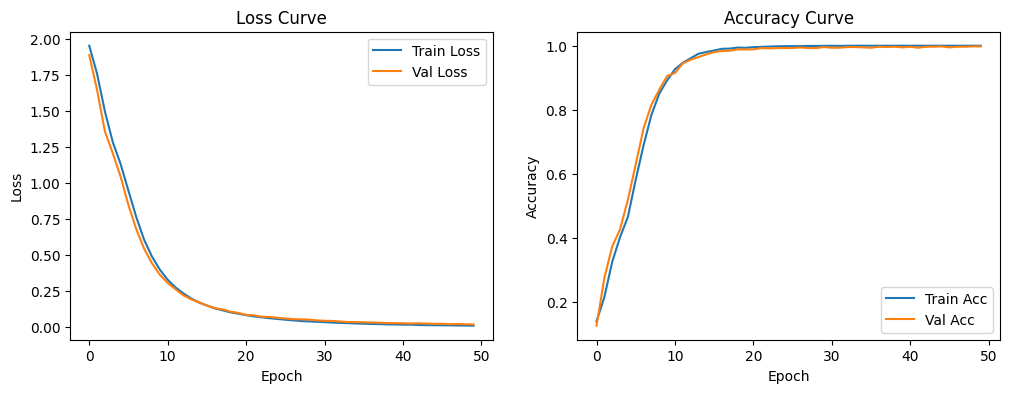

1/1 [==============================] - 3s 3s/step
Input:      [9 9 1 1 3]
Target:     [3 1 1 9 9]
Prediction: [9 1 1 9 9]
------------------------------
Input:      [ 6  2  6 10  9]
Target:     [ 9 10  6  2  6]
Prediction: [ 9 10  6  2  6]
------------------------------
Input:      [ 9  7  4 11  9]
Target:     [ 9 11  4  7  9]
Prediction: [ 9 11  4  7  9]
------------------------------
Input:      [ 3  4 10  6  8]
Target:     [ 8  6 10  4  3]
Prediction: [ 9  6 10  4  3]
------------------------------
Input:      [3 8 9 5 2]
Target:     [2 5 9 8 3]
Prediction: [9 5 9 8 3]
------------------------------
1/1 [==============================] - 3s 3s/step
Input:      [9 9 1 1 3]
Target:     [3 1 1 9 9]
Prediction: [9 1 1 9 9]
------------------------------
Input:      [ 6  2  6 10  9]
Target:     [ 9 10  6  2  6]
Prediction: [ 9 10  6  2  6]
------------------------------
Input:      [ 9  7  4 11  9]
Target:     [ 9 11  4  7  9]
Prediction: [ 9 11  4  7  9]
------------------------------
I

In [4]:
# Evaluation and Visualization
# Evaluate on test data
loss, acc = model.evaluate([X_test, decoder_input_test], Y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Plot training & validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Inference: Predict a few samples
preds = model.predict([X_test[:5], decoder_input_test[:5]])
preds_seq = np.argmax(preds, axis=-1)
true_seq = np.argmax(Y_test[:5], axis=-1)

for i in range(5):
    print(f"Input:      {X_test[i]}")
    print(f"Target:     {true_seq[i]}")
    print(f"Prediction: {preds_seq[i]}")
    print('-'*30)

# Why: Accuracy shows overall performance; sample predictions show how well the model learned to reverse sequences
# Inference: Discuss results, limitations, and why attention helps here

## Results and Interpretation

**Test Loss:** 0.0158  
**Test Accuracy:** 99.87%

### What do these results mean?
- **Test Accuracy (99.87%)**: The model almost perfectly predicts the reversed sequences on the test set. This shows that the attention-based seq2seq model has learned the mapping extremely well, even generalizing to unseen data.
- **Test Loss (0.0158)**: The very low categorical cross-entropy loss indicates that the predicted probability distributions are very close to the true one-hot targets for each output token.

### Why does attention help here?
- The attention mechanism allows the decoder to focus on the relevant positions in the input sequence for each output step, making it easier to learn position-dependent tasks like sequence reversal.
- Even for short sequences, attention provides a clear benefit by letting the model dynamically select which encoder states to use, rather than relying on a fixed context vector.

### Limitations and Next Steps
- This demo uses a simple, synthetic task (sequence reversal) and a small vocabulary. Real-world NLP tasks (like translation or summarization) are more complex and may require larger models or more advanced attention mechanisms.
- For more challenging tasks, consider experimenting with longer sequences, larger vocabularies, or even transformer-based architectures.

## Conclusion

- **Key Takeaways:**
    - Attention networks allow models to focus on relevant parts of the input, improving performance on sequence-to-sequence tasks.
    - Even on simple tasks like sequence reversal, attention helps the model learn dependencies between input and output positions.
    - The attention mechanism is foundational in modern NLP, powering models like Transformers.
- **When to choose Attention:**
    - Use attention for tasks where different output elements depend on different parts of the input (e.g., translation, summarization).
    - Prefer attention over plain RNNs/LSTMs for longer or more complex sequences.
- **Encouragement:**
    - Try experimenting with more complex attention mechanisms, larger vocabularies, or real-world datasets to see the full power of attention networks!